In [0]:
df = spark.read.csv("dbfs:/FileStore/shared_uploads/vmonala@gmu.edu/cleaned_data_withoutcovidandroomtype-7.csv", header=True, inferSchema=True)

In [0]:
df = df.drop('availability_365')

In [0]:
from pyspark.sql.functions import isnan, when, count, col

# Calculate the count of null values in each column
null_counts = df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df.columns])

# Convert the result to a dictionary for easier visualization
null_counts_dict = null_counts.first().asDict()

# Display the null counts
for column, count in null_counts_dict.items():
    print(f"Column '{column}': {count} null values")


Column 'id': 0 null values
Column 'name': 6 null values
Column 'host_id': 37 null values
Column 'host_name': 40 null values
Column 'neighbourhood': 37 null values
Column 'latitude': 37 null values
Column 'longitude': 37 null values
Column 'room_type': 37 null values
Column 'price': 37 null values
Column 'minimum_nights': 37 null values
Column 'number_of_reviews': 37 null values
Column 'booking_date': 37 null values
Column 'reviews_per_month': 37 null values
Column 'calculated_host_listings_count': 37 null values
Column 'number_of_reviews_ltm': 37 null values
Column 'date': 37 null values
Column 'day_of_week': 37 null values
Column 'day_type_Weekday': 37 null values
Column 'day_type_Weekend': 37 null values
Column 'Number of Days Booked': 37 null values
Column 'Booking Rate': 37 null values
Column 'Booking Rate Category': 68 null values


In [0]:
# Remove rows with any null values
df = df.dropna()


In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

indexer = StringIndexer(inputCol="room_type", outputCol="room_type_Index")
df = indexer.fit(df).transform(df)

encoder = OneHotEncoder(inputCols=["room_type_Index"], outputCols=["room_type_Encoded"])
df = encoder.fit(df).transform(df)

In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import IntegerType, FloatType
df = df.withColumn("price", col("price").cast(FloatType()))
df = df.withColumn("minimum_nights", col("minimum_nights").cast(IntegerType()))
df = df.withColumn("reviews_per_month", col("reviews_per_month").cast(FloatType()))

# Check the schema to ensure the changes have been applied
df.printSchema()


root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: string (nullable = true)
 |-- host_name: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- price: float (nullable = true)
 |-- minimum_nights: integer (nullable = true)
 |-- number_of_reviews: string (nullable = true)
 |-- booking_date: string (nullable = true)
 |-- reviews_per_month: float (nullable = true)
 |-- calculated_host_listings_count: string (nullable = true)
 |-- number_of_reviews_ltm: string (nullable = true)
 |-- date: string (nullable = true)
 |-- day_of_week: string (nullable = true)
 |-- day_type_Weekday: string (nullable = true)
 |-- day_type_Weekend: string (nullable = true)
 |-- Number of Days Booked: string (nullable = true)
 |-- Booking Rate: string (nullable = true)
 |-- Booking Rate Category: string (nullable = true)
 |-- room_type

In [0]:
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import col

df = df.withColumn("price", col("price").cast("float"))
df = df.withColumn("minimum_nights", col("minimum_nights").cast("float"))
df = df.withColumn("reviews_per_month", col("reviews_per_month").cast("float"))

# Using VectorAssembler with handleInvalid = "skip" to ignore rows with any null values
assembler = VectorAssembler(
    inputCols=["price", "minimum_nights", "reviews_per_month"],
    outputCol="features",
    handleInvalid="skip" 
)

# Transform the data
df=assembler.transform(df)
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
df = scaler.fit(df).transform(df)




In [0]:
# PCA
pca = PCA(k=3, inputCol="scaledFeatures", outputCol="pcaFeatures")
model = pca.fit(df)
df = model.transform(df)

# Print Eigenvalues to understand explained variance
print("Explained Variance:", model.explainedVariance.toArray())

# Print PCA components
print("PCA Components:\n", model.pc)

Explained Variance: [0.37262792 0.3326313  0.29474078]
PCA Components:
 DenseMatrix([[-0.17473366,  0.97763344,  0.11705125],
             [-0.68904445, -0.20633279,  0.69472622],
             [ 0.7033391 ,  0.04073855,  0.70968618]])


In [0]:
from pyspark.ml.feature import StringIndexer

# Create a StringIndexer to convert the "Booking Rate Category" column into numerical labels
indexer = StringIndexer(inputCol="Booking Rate Category", outputCol="label", handleInvalid="keep")

# Fit and transform the DataFrame to add the numerical labels
df = indexer.fit(df).transform(df)


In [0]:
train_df, test_df = df.randomSplit([0.7, 0.3], seed=42)

In [0]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="pcaFeatures", labelCol="label", maxIter=10)
lrModel = lr.fit(train_df)

Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Make predictions on the test data
predictions = lrModel.transform(test_df)

# Select prediction and label columns for evaluation
predictionAndLabels = predictions.select("prediction", "label")

# Create a MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(metricName="accuracy")

# Calculate accuracy
accuracy = evaluator.evaluate(predictionAndLabels)

# Print accuracy
print("Accuracy:", accuracy)

Accuracy: 0.4266917293233083


/databricks/spark/python/pyspark/sql/context.py:165: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


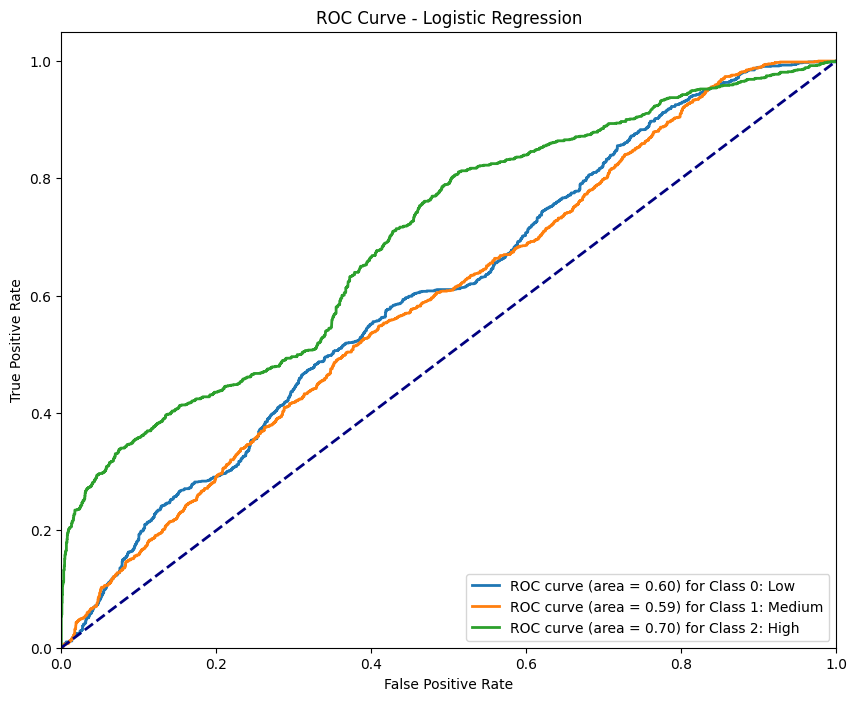

In [0]:
from pyspark.mllib.evaluation import MulticlassMetrics
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#ROC curve for Logistic Regression

# Make predictions
predictions_lr = lrModel.transform(test_df)

# Convert the DataFrame to an RDD
predictionAndLabels_lr = predictions_lr.select("prediction", "label").rdd.map(lambda row: (float(row['prediction']), float(row['label'])))

# Create MulticlassMetrics object
metrics_lr = MulticlassMetrics(predictionAndLabels_lr)

# Compute ROC curve for each class
fprs_lr = dict()
tprs_lr = dict()
roc_aucs_lr = dict()

# Get unique labels
labels_lr = sorted(set(predictions_lr.select("label").rdd.flatMap(lambda x: x).collect()))

# Map label indices to class names
label_names_lr = {0: "Class 0: Low", 1: "Class 1: Medium", 2: "Class 2: High"}  

for label in labels_lr:
    # Extract probabilities
    probabilities = predictions_lr.select("probability").rdd.map(lambda x: x[0][int(label)]).collect()
    
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(predictionAndLabels_lr.map(lambda x: 1.0 if x[1] == label else 0.0).collect(), probabilities)
    
    fprs_lr[label] = fpr
    tprs_lr[label] = tpr
    roc_aucs_lr[label] = auc(fpr, tpr)


# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for label in labels_lr:
    plt.plot(fprs_lr[label], tprs_lr[label], lw=2, label='ROC curve (area = %0.2f) for %s' % (roc_aucs_lr[label], label_names_lr[label]))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

In [0]:
from pyspark.ml.classification import RandomForestClassifier

# Train a RandomForest model
rf = RandomForestClassifier(featuresCol="pcaFeatures", labelCol="label")
rfModel = rf.fit(train_df)

# Feature importance
print("Feature Importances:", rfModel.featureImportances)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Feature Importances: (3,[0,1,2],[0.21005463207758196,0.11273688217693274,0.6772084857454852])


In [0]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
predictions = rfModel.transform(test_df)

# Select prediction and label columns for evaluation
predictionAndLabels = predictions.select("prediction", "label")

# Create a MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(metricName="accuracy")

# Calculate accuracy
accuracy = evaluator.evaluate(predictionAndLabels)

print("Accuracy:", accuracy)

Accuracy: 0.4892588614393126


/databricks/spark/python/pyspark/sql/context.py:165: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


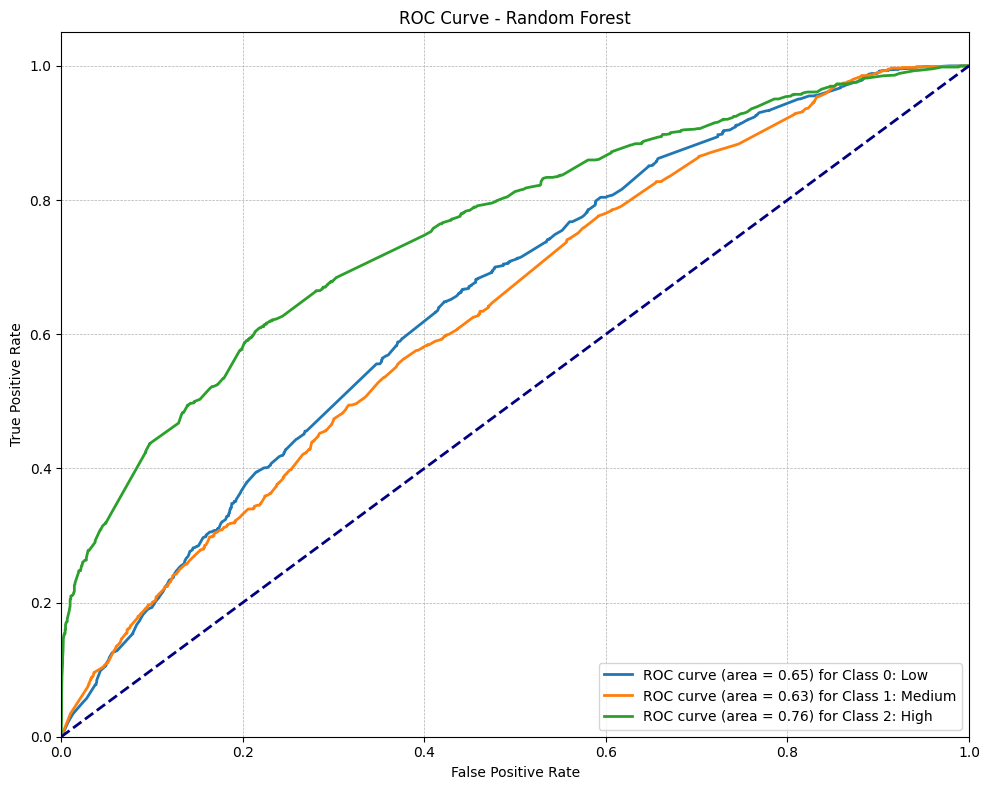

In [0]:
#ROC Curve for Random Forest

# Make predictions using the Logistic Regression model
predictions_rf = rfModel.transform(test_df)

# Convert the DataFrame to an RDD
predictionAndLabels_rf = predictions_rf.select("prediction", "label").rdd.map(lambda row: (float(row['prediction']), float(row['label'])))

# Create MulticlassMetrics object
metrics_rf = MulticlassMetrics(predictionAndLabels_rf)

# Compute ROC curve for each class
fprs_rf = dict()
tprs_rf = dict()
roc_aucs_rf = dict()

# Get unique labels
labels_rf = sorted(set(predictions_rf.select("label").rdd.flatMap(lambda x: x).collect()))

# Map label indices to class names
label_names_rf = {0: "Class 0: Low", 1: "Class 1: Medium", 2: "Class 2: High"}

for label in labels_lr:
    # Extract probabilities
    probabilities = predictions_rf.select("probability").rdd.map(lambda x: x[0][int(label)]).collect()
    
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(predictionAndLabels_rf.map(lambda x: 1.0 if x[1] == label else 0.0).collect(), probabilities)
    
    fprs_rf[label] = fpr
    tprs_rf[label] = tpr
    roc_aucs_rf[label] = auc(fpr, tpr)

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for label in labels_rf:
    plt.plot(fprs_rf[label], tprs_rf[label], lw=2, label='ROC curve (area = %0.2f) for %s' % (roc_aucs_rf[label], label_names_rf[label]))

# Plot the random guessing line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set plot properties
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

# Show plot
plt.show()